# Models

In [1]:
import numpy as np
from scipy.stats import gamma, norm
# get truncated gamma and normal distributions
from scipy.stats import truncnorm
# from truncnorm get gamma and normal distributions


class SlopeMAPPerceptual:
    def __init__(self, *args, **kwargs):
        # Leak parameter
        self.leak = kwargs.get('leak', 0)
        # x values = forcefield values
        self.x = kwargs.get('x', np.linspace(-1, 1, 9).round(2))
        if not isinstance(self.x, np.ndarray):
            self.x = np.array(list(self.x))
        
        # Initialize outcome-based prior
        # Slope prior mean and standard deviation
        self.slope_prior_mean = kwargs.get('slope_prior_mean', 0.0)  # Default mean to 0
        self.slope_prior_std = kwargs.get('slope_prior_std', 1.0)    # Default std to 1.0
        
        # Ensure the prior standard deviation is positive
        self.slope_prior_std = max(0.001, self.slope_prior_std)  # Set a minimum value
        
        # Possible values for the slope
        self.slope_range = kwargs.get('slope_range', np.arange(-10, 10, 0.1))
        
        # Initialize log-posterior for the slope with prior
        self.lp_slope = np.log(norm.pdf(self.slope_range, self.slope_prior_mean, self.slope_prior_std))
        
        # Define logit function
        self.logit = lambda x: 1 / (1 + np.exp(x))

        self.binary = kwargs.get('binary', True)
        
    def perceptual_update(self, choice, outcome, spaceship_estimate=None):
        """Update the log-posterior of the slope based on observed data."""
        if self.binary:
            v = self.slope_range * choice
            v = v - v * 2 * outcome  # Switch to negative if forcefield destroyed
    
            # Binary outcome likelihood
            ll = np.log(self.logit(v))
        else:
           # Continuous outcome: outcome = sigmoid(slope * x) * spaceship reward
            logits = self.slope_range * choice

            # logistic probabilities
            p = self.logit(logits)

            # in the generative process of exp. 3, spaceship rewards is
            # multiplied by shield value to produce an outcome
            # Use observed outcome and estimated spaceship to derive implied sigmoid output
            pred_outcomes = np.clip(outcome / spaceship_estimate, 1e-6, 1 - 1e-6)
            # pred_outcomes = p * (spaceship_estimate * 2)

            # gaussian likelihood: compare each pred_outcome to the obtained outcome
            likelihoods = np.exp(-0.5 * ((p-pred_outcomes) ** 2) / 0.1)
            # likelihoods = np.exp(-0.5 * ((outcome - pred_outcomes) ** 2) / 0.2)

            # posterior
            posterior = likelihoods / np.sum(likelihoods)

            ll = np.log(posterior)

        # Update log posterior
        self.lp_slope += ll
           
    def predict_shield_p(self, shields):
        """Predict outcomes (linear or logit) for given forcefields."""
        # Predict for 2 displayed forcefields
        x = np.arange(len(self.x))
        to_select = x[np.isin(self.x, shields)]
        slope = -self.get_slope() * int(self.binary) + self.get_slope() * int(not self.binary)
        return self.logit(slope * self.x[to_select])
    
    def get_slope(self):
        """Compute the current slope as the weighted mean of the slope range."""
        w = np.exp(self.lp_slope - np.max(self.lp_slope))
        slope = np.sum(w * self.slope_range) / np.sum(w)
        return slope


class NormativeValue:
    def __init__(self, spaceship_ids, mu0=.5, kappa0=1, alpha0=2, beta0=0.1):
        """
        Bayesian reward model using Normal-Gamma conjugate prior for multiple spaceships.

        Parameters:
            spaceship_ids : list of spaceship identifiers (ints or strings)
            mu0, kappa0, alpha0, beta0 : prior hyperparameters for all spaceships
        """
        self.mu0 = mu0
        self.kappa0 = kappa0
        self.alpha0 = alpha0
        self.beta0 = beta0

        self.data = {sid: [] for sid in spaceship_ids}

    def value_update(self, spaceship_id, reward):
        """
        Add an observed reward for a specific spaceship.

        Parameters:
            spaceship_id : ID of the spaceship
            reward : observed scalar reward
        """
        if spaceship_id not in self.data:
            raise ValueError(f"Unknown spaceship ID: {spaceship_id}")
        self.data[spaceship_id].append(reward)

    def compute_posterior(self, spaceship_id):
        """
        Compute the posterior parameters for a given spaceship.
        """
        if self.model == 'perceptual':
            return 
            
        xi = np.array(self.data[spaceship_id])
        n = len(xi)

        if n == 0:
            return self.mu0, self.kappa0, self.alpha0, self.beta0

        x_bar = xi.mean()
        S = np.sum((xi - x_bar) ** 2)

        kappa_n = self.kappa0 + n
        mu_n = (self.kappa0 * self.mu0 + n * x_bar) / kappa_n
        alpha_n = self.alpha0 + n / 2
        beta_n = self.beta0 + 0.5 * S + (self.kappa0 * n * (x_bar - self.mu0) ** 2) / (2 * kappa_n)

        return mu_n, kappa_n, alpha_n, beta_n

    def posterior_predictive_mean(self, spaceship_id):
        """
        Return the expected value (mean) of the predictive distribution for a spaceship.
        """
        if self.model == 'perceptual':
            return 1.0
        mu_n, _, _, _ = self.compute_posterior(spaceship_id)
        return mu_n

    def sample_posterior(self, spaceship_id, n_samples=1000):
        """
        Sample possible mean rewards for a spaceship from the posterior predictive distribution.
        """
        mu_n, kappa_n, alpha_n, beta_n = self.compute_posterior(spaceship_id)

        tau_samples = gamma.rvs(a=alpha_n, scale=1 / beta_n, size=n_samples)
        mu_samples = norm.rvs(loc=mu_n, scale=1 / np.sqrt(kappa_n * tau_samples))
        #truncated normal distribution
        mu_samples = truncnorm.rvs(a=0, b=1, loc=mu_samples, scale=1 / np.sqrt(kappa_n * tau_samples))

        return mu_samples

    def reset(self, spaceship_id=None):
        """
        Reset observations for one or all spaceships.
        """
        if spaceship_id is None:
            for sid in self.data:
                self.data[sid] = []
        else:
            self.data[spaceship_id] = []

class NormativePolicy(NormativeValue):
    def __init__(self, spaceship_ids, mu0=.5, kappa0=1, alpha0=2, beta0=0.1,
                 burn_in=500, samples=1000, model=False, omega=0, beta=1, binary=True):
        NormativeValue.__init__(self, spaceship_ids, mu0, kappa0, alpha0, beta0)
        if model == 'gibbs':
            print('model is gibbs')
            self.perceptual = NormativePerceptual(burn_in=burn_in, samples=samples)
            self.perceptual.model = 'gibbs'
        else:
            # print('model is map')
            self.perceptual = SlopeMAPPerceptual(binary=binary)
            self.perceptual.model = 'map'
        self.perceptual_update = self.perceptual.perceptual_update
        self.predict_shield_p = self.perceptual.predict_shield_p
        
        self.omega = omega
        self.beta = beta
        self.model = model
        self.v_log_ratio_list = []
        self.p_log_ratio_list = []
        self.v_log_ratio = 0
        self.p_log_ratio = 0

    def expected_reward(self, spaceship_id, shield_strength):
        """
        Compute the expected reward for a spaceship given a shield strength z

        Parameters:
            spaceship_id : spaceship ID
            shield_strength : scalar z*

        Returns:
            Expected reward E[Y | z*, Z, B, X]
        """
        # Step 1: compute P(b=1 | z*) from probit model
        p_success = 1.0  # Default if no shield strength is provided
        if ~np.isnan(shield_strength) and self.model != 'value':
            p_success = self.perceptual.predict_shield_p(shield_strength)

        # Step 2: compute E[μ | X] from reward model
        E_mu = 1.0 
        if self.model != 'perceptual':
            mu_n, kappa_n, _, _ = self.compute_posterior(spaceship_id)
            E_mu = mu_n

        # Step 3: combine both
        return p_success, E_mu

    def get_spaceship_mean(self, spaceship_id):
        E_mu = 1.0
        if self.model != 'perceptual':
            mu_n, kappa_n, _, _ = self.compute_posterior(spaceship_id)
            E_mu = mu_n
        return E_mu
    
    def get_shield_probability(self, shield_strength):
        p_success = 1.0
        if ~np.isnan(shield_strength) and self.model != 'value':
            p_success = self.perceptual.predict_shield_p(shield_strength)
        return p_success

    def choose(self, spaceships, shields):
        """
        compute the expected reward for a spaceship given a shield strength z
        and select the one that tends to maximize it.
        """

        p1, p2 = [self.get_shield_probability(x) for x in shields]
        v1, v2 = [self.get_spaceship_mean(x) for x in spaceships]
    
        v_lr = np.log(v1) - np.log(v2)
        p_lr = np.log(p1) - np.log(p2)

        self.v_log_ratio_list.append(v_lr)  
        self.p_log_ratio_list.append(p_lr)

        # v_lr = v_lr / 0.59
        # p_lr = p_lr / 0.74        
        
        dv = (1-self.omega) * v_lr + self.omega * p_lr

        return int(np.random.random() > (1/(1 + np.exp(self.beta*-dv))))
    
    def get_likelihood(self, spaceships, shields):
        """
        computes the likelihood of both options
        given the shield strengths and  spaceships
        """

        p1, p2 = [self.get_shield_probability(x) for x in shields]
        v1, v2 = [self.get_spaceship_mean(x) for x in spaceships]
    
        v_lr = np.log(v1) - np.log(v2)
        p_lr = np.log(p1) - np.log(p2)

        # v_lr = v_lr / 0.59
        # p_lr = p_lr / 0.74        
        
        dv = (1-self.omega) * v_lr + self.omega * p_lr

        # estimated p of choosing option 1
        ep1 = 1/(1 + np.exp(self.beta*-dv))

        return [ep1, 1-ep1]
        
        
    def choose2(self, spaceships, shields):
        """
        compute the expected reward for a spaceship given a shield strength z
        and select the one that tends to maximize it.
        """

        p1, p2 = [self.get_shield_probability(x) for x in shields]
        v1, v2 = [self.get_spaceship_mean(x) for x in spaceships]
    
        self.v_log_ratio = np.log(v1) - np.log(v2)
        self.p_log_ratio = np.log(p1) - np.log(p2)

        # # v_lr = v_lr / np.std(self.v_log_ratio_list)
        # # p_lr = p_lr / np.std(self.p_log_ratio_list)

        # dv = (1-self.omega) * v_lr + self.omega * p_lr

        # return int(np.random.random() > (1/(1 + np.exp(self.beta*-dv))))
        
        # # not a dic now but two arrays
        expected_rewards = [
            sid*shield
            for sid, shield in zip([v1, v2], [p1, p2])
        ]
        return np.argmax(expected_rewards)

        #best_id = max(expected_rewards, key=expected_rewards.get)
        

class SaliencyPolicy:
    def __init__(self, beta=1):
        self.beta = beta

    def get_likelihood(self, spaceships, shields):
        # shields are the visual cues (ff values)
        s1, s2 = shields
        dv = s1 - s2
        
        # Softmax probability of choosing option 1
        ep1 = 1 / (1 + np.exp(self.beta * -dv))
        return [ep1, 1-ep1]

    def choose(self, spaceships, shields):
        ep1, _ = self.get_likelihood(spaceships, shields)
        return int(np.random.random() > ep1)


In [2]:
import sys
sys.path.append('..')

from src.visualization import plot_settings
import pandas as pd
import numpy as np
import seaborn as sns

df = pd.read_csv('../data/raw/fullpilot1466.csv')
df2 = pd.read_csv('../data/raw/fullpilot13_22.csv')
df3 = pd.read_csv('../data/raw/test/spaceprl(26).csv')

df = df[df.expName.isin(['FullPilot12', 'FullPilot13', 'FullPilot14', ])]
df2 = df2[df2.expName.isin(['FullPilot12', 'FullPilot13'])]
df3 = df3[df3.expName.isin(['FullPilot12_2'])]
#concat df and df3
df = pd.concat([df, df3])

df = df.groupby('prolificID').filter(lambda x: len(x) >= 483)
df2 = df2.groupby('prolificID').filter(lambda x: len(x) >= 483)

df = pd.concat([df, df2])
# df = df.groupby('prolificID').filter(lambda x: len(x) <= 432)
# keep  prolificIDs that are more than 10 characters
df = df[df.prolificID.str.len() > 10]
# show prolificIDs

expName = ['FullPilot12_2',  'FullPilot12', 'FullPilot13', 'FullPilot14']

df['opti_ss'] = ((df.m1 > df.m2) & (df.choice==1)) | ((df.m1 < df.m2) & (df.choice==2))
df['opti_ff'] = ((df.p1 > df.p2) & (df.choice==1)) | ((df.p1 < df.p2) & (df.choice==2))
df['opti_ev'] = ((df.ev1 > df.ev2) & (df.choice==1)) | ((df.ev1 < df.ev2) & (df.choice==2))
df['chosen_p'] = np.where(df.choice == 1, df.p1, df.p2)
df['chosen_m'] = np.where(df.choice == 1, df.m1, df.m2)

df.loc[df.expName=='FullPilot14', 'destroyed'] = 1
df['outcome'] = (df.outcome1 * (df.choice == 1) * df.destroyed) + (df.outcome2 * (df.choice == 2) * df.destroyed)



df = df[df.expName.isin(expName)]
print(f'N = {len(df.prolificID.unique())}')

# remove duplicates and only take first based on prolificID, t, session
df = df.drop_duplicates(subset=['prolificID', 't', 'session'])

# replace all of the above by df
# we have m1, m2 and p1, p2, we need to say what option is riskier (higher variance) 
df['var1'] = df.p1 * (df.m1 - df.ev1)**2 + (1 - df.p1) * (0 - df.ev1)**2

df['var2'] = df.p2 * (df.m2 - df.ev2)**2 + (1 - df.p2) * (0 - df.ev2)**2
df['riskier'] = np.where(df.var1 > df.var2, 1, 2)
df['chose_safe'] = np.where(df.choice != df.riskier, 1, 0)
df['chose_risky'] = np.where(df.choice == df.riskier, 1, 0)


df['outcome'] = (df.outcome1 * (df.choice == 1) * df.destroyed) + (df.outcome2 * (df.choice == 2) * df.destroyed)
df['outcome'] /= 1000
# fireTime is in ms, convert to seconds
df['fireTime'] = df.fireTime / 1000
# df['trial'] = ((df.t.max()+1) * (df.session-2)) + df.t
df['trial'] = df.t
df['s'] = list(zip(df.m1, df.m2))

print('Number of participants:', df.prolificID.nunique())
map_prolificID = {pid: i for i, pid in enumerate(df.prolificID.unique())}
df['id'] = df.prolificID.map(map_prolificID)

# df['pair'] = df.pair.apply(lambda x: 0 if x < 0 else x)

# define probabilities
x = np.linspace(-1, 1, 9)
pp = (1/(1+np.exp(-2*x))).round(2)


slope = 2
logistic = lambda x: 1/(1+np.exp(-slope*x))
map_ff_values = {logistic(i).round(2):i for i in np.linspace(-1, 1, 9)}
map_ff_values[1] = 1
df['agent'] = df.prolificID

df['s'] = list(zip(df.m1, df.m2))
df['a'] = (df.choice - 1).astype(int)  # Convert choice to 1 or 0
df['r'] = df.outcome
df['ff1'] = df.p1.map(map_ff_values)
df['ff2'] = df.p2.map(map_ff_values)
# if (df.p1.unique()[0]==1):
    # df['ff1'] = .25
    # df['ff2'] = .25
df['destroy'] = df.destroyed


N = 245
Number of participants: 245


In [3]:
session = 3
df_ = df[(df.session==session)].groupby(['prolificID'], as_index=False).mean(numeric_only=True)

import scipy.stats as stats

df_['delta'] = df_.opti_ff - df_.opti_ss

df_['opti_ff'] = df_.opti_ff.astype(float)
df_['opti_ss'] = df_.opti_ss.astype(float)
df_['delta'] = df_.delta.astype(float)
df['opti_ff'] = df['opti_ff'].astype(float)
df['opti_ss'] = df['opti_ss'].astype(float)
         
df2 = df[(df.session==session)]

def get_group2(row):
    opti_ff = df2[df2.prolificID==row.prolificID].opti_ff
    opti_ss = df2[df2.prolificID==row.prolificID].opti_ss
    ttest = stats.ttest_rel(opti_ff, opti_ss)
    p = ttest.pvalue
    t = ttest.statistic
    p_ss = stats.ttest_1samp(opti_ss, 0.5, alternative='greater').pvalue < 0.05 
    p_ff = stats.ttest_1samp(opti_ff, 0.5, alternative='greater').pvalue < 0.05

    if p > 0.05:
        if p_ss and p_ff:
            return 'balanced'
        if p_ss:
            return 'value'
        if p_ff:
            return 'perceptual'
        return 'random'
    
    if t > 0 and p_ff:
        return 'perceptual'
    if t < 0  and p_ss:
        return 'value'

    return 'random'

def get_group(row):
    opti_ff = df2[df2.prolificID==row.prolificID].opti_ff
    opti_ss = df2[df2.prolificID==row.prolificID].opti_ss
    p_ss = stats.ttest_1samp(opti_ss, 0.5, alternative='greater').pvalue < 0.05 
    p_ff = stats.ttest_1samp(opti_ff, 0.5, alternative='greater').pvalue < 0.05

    if p_ss and p_ff:
        return 'combined'
        

    if p_ff:
        return 'perceptual'
    if p_ss:
        return 'value'

    return 'random'
    # raise ValueError('unexpected value')

df_['group'] = df_.apply(get_group, axis=1)

df['group'] = df['prolificID'].map(df_.set_index('prolificID')['group'])

# df = df[df.group != 'random']
print(len(df.prolificID.unique()))

245


In [4]:
import itertools
from scipy.special import logsumexp
from scipy.stats import norm


def fit(x0, *args):
    # print('Running fit...')
    pid, fit_training, exp, model, session, ntrials, s, a, r, destroy, ff1, ff2, ff_values = args
    try:
        _ = len(x0)
    except:
        x0 = [x0]

    if model  in ('map', 'value', 'perceptual'):
        omega = x0[0]
        beta = x0[1]
        m = NormativePolicy(
            spaceship_ids=[280, 380, 500, 620, 720],
            omega=omega,
            beta=beta,
            binary=exp!='FullPilot14',
        )
    elif model == 'saliency':
        beta = x0[0]
        m = SaliencyPolicy(beta=beta)
    else:
        raise ValueError(f"Unknown model: {model}")
    
    logit = lambda x: 1 / (1 + np.exp(x))

    if model != 'random':

        ll = 0
        for t in range(ntrials):

            ff_chosen = [ff1[t], ff2[t]][a[t]]
            p_chosen = logit(-2*ff_chosen).round(2)

            if model != 'saliency':
                if session[t] in (1, 3) and ('value' not in model):
                    if exp == 'FullPilot14':
                        # spaceship_estimates = np.array([
                        #     m.posterior_predictive_mean(sid)
                        #     for sid in [280, 380, 500, 620, 720]
                        # ])
                        if session[t] == 1:
                            spaceship_estimate = .5
                        else:
                            spaceship_estimate = m.posterior_predictive_mean(s[t][a[t]])
                        m.perceptual_update(ff_chosen, r[t], spaceship_estimate=spaceship_estimate)
                    else:
                        m.perceptual_update(ff_chosen, destroy[t])

                if session[t] in (0, 2, 3) and ('perceptual' not in model):
                    if destroy[t]:
                        m.value_update(s[t][a[t]], r[t])
                    if (not destroy[t]) and (exp == 'FullPilot13'):
                        m.value_update(s[t][a[t]], r[t]/2)

            if session[t] in (3, ) or fit_training:
                p_of_choices = m.get_likelihood(s[t], [ff1[t], ff2[t]])
                ll += np.log(p_of_choices[a[t]] + 1e-10)
    else:
        ll = 0
        for t in range(ntrials):
            ll += np.log(np.exp([.5, .5] - logsumexp([.5, .5])))[0]

    beta_prior_logpdf = norm.logpdf(beta, loc=1e5/2, scale=5)
    # check that beta prior is a valid number
    if np.isnan(beta_prior_logpdf):
        beta_prior_logpdf = 0
    elif np.isinf(beta_prior_logpdf):
        beta_prior_logpdf = 0
    # ll += beta_prior_logpdf

    return -ll,


In [39]:
exp = ['FullPilot12','FullPilot13', 'FullPilot14']
df.expName.unique()


array(['FullPilot14', 'FullPilot12_2', 'FullPilot12', 'FullPilot13'],
      dtype=object)

In [5]:
from joblib import Parallel, delayed
import itertools
from pybads import BADS
import pandas as pd
from tqdm.notebook import tqdm
import numpy as np

# Assuming df is predefined
exp = ['FullPilot12', 'FullPilot12_2', 'FullPilot13', 'FullPilot14']
agents = df[(df.expName.isin(exp))].agent.unique()
models = ['map', 'saliency']
parallel = True 

# Function to optimize for one agent and model
def optimize_agent_model(agent, model, agent_data, fit_training=False):
    # print('Running optimization for', agent, model)
    df2 = agent_data
    # drop rows where session==3 and pair is not in [0,1]
    
    # Condition to drop rows
    if not fit_training:
        condition = ~((df2['session'] == 3) & (~df2['pair'].isin([0, 1])))
    else:
        condition = (df2['session'].isin([0, 2]))
    # # # Drop rows meeting the condition, keeping other rows intact
    df2 = df2.loc[condition]
    # df2 = df2[df2.session==3]

    s, a, r = df2.s.values, df2.a.values, df2.r.values
    ff1, ff2 = df2.ff1.values, df2.ff2.values
    session = df2.session.values
    destroy = df2.destroy.values
    ntrials = df2.shape[0]
    exp = df2.expName.values[0]
    pid = map_prolificID[df2.prolificID.values[0]]

    def target(x):
        return fit(x, *(pid, fit_training, exp, model, session, ntrials, s, a, r, destroy, ff1, ff2, map_ff_values.values()))[0]

    if model == 'saliency':
        lower_bounds = np.array([0])
        upper_bounds = np.array([1e4])
        x0 = np.array([5])
        
        plausible_lower_bounds = np.array([1])
        plausible_upper_bounds = np.array([50])

    elif  any(s in model for s in ['absolute', 'log-ratio', 'absolute-var', 'map', 'perceptual', 'value']):
        lower_bounds = np.array([0, 0])
        upper_bounds = np.array([1, 1e4])
        x0 = np.array([0.5, 5])
   
        # To prevent triggering the "bads:StrictBoundsTooClose" or similar errors:
        # Ensure plausible bounds are within the lower and upper bounds.

        plausible_lower_bounds = np.array([0.05, 1])  # Should be slightly above lower_bounds but still below upper_bounds
        plausible_upper_bounds = np.array([0.95, 50])  # Should be slightly below upper_bounds but still above plausible_lower_bounds

    bads = BADS(
        target,
        x0=x0,
        lower_bounds=lower_bounds,
        upper_bounds=upper_bounds,
        plausible_lower_bounds=plausible_lower_bounds,
        plausible_upper_bounds=plausible_upper_bounds,
        options={'display': 'off'}
    )

    optimize_result = bads.optimize()
    
    if model == 'saliency':
        return {'agent': agent, 'model': model, 'omega': np.nan, 'beta': optimize_result.x[0], 'll': optimize_result.fval, 'group': 
            df2.group.values[0], 'ntrials': ntrials, 'exp': exp, 'prolificID': df2.prolificID.values[0]}
    
    return {'agent': agent, 'model': model, 'omega': optimize_result.x[0], 'beta': optimize_result.x[1], 'll': optimize_result.fval, 'group': 
            df2.group.values[0], 'ntrials': ntrials, 'exp': exp, 'prolificID': df2.prolificID.values[0]}


from joblib import Parallel, delayed
from tqdm_joblib import tqdm_joblib
from tqdm_joblib import ParallelPbar
import itertools

# Prepare list of all agent-model pairs
tasks = itertools.product(agents, models)

results = []
parallel = True
fit_training = False

if parallel:
    # Parallel execution with notebook-friendly progress bar
    results = []
    for result in ParallelPbar('N sub')(n_jobs=-2, # Use all available cores except 1 to keep the system responsive
                            backend='loky' 
    )(delayed(optimize_agent_model)(agent, model, df[df.agent == agent].sort_values('t'), fit_training) for agent, model in tasks):
        results.append(result)

else:

    # non parallel version
    results = []
    for agent, model in tasks:
        results.append(optimize_agent_model(agent, model, df[df.agent == agent].sort_values('t')))
        # pbar.update()

df_fit = pd.DataFrame(results)


c:\Users\garciaba\.pyenv\pyenv-win\versions\3.9.12\lib\site-packages\tqdm_joblib\__init__.py:4: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


N sub:   0%|          | 0/490 [00:00<?, ?it/s]

In [38]:
groups = df_fit[(df_fit.group!='random') & (df_fit.exp!='FullPilot12_2')].groupby('exp').group.value_counts()

# test the proportions with chi2_contingency
from scipy.stats import chi2_contingency
contingency_table = pd.crosstab(df_fit.exp, df_fit.group)
chi2, p, dof, expected = chi2_contingency(contingency_table)
print('Chi2:', chi2)   
print('p-value:', p)


Chi2: 31.869653865066823
p-value: 0.00020972675095454944


In [10]:
# data = df_fit[df_fit.model=='map'].copy()
# data['group'] = data.group.astype('category')
# data['group'] = data.apply(lambda x: 'value' if x.omega < 0.33 else 'perceptual' if x.omega > 0.66 else 'combined', axis=1)

df_fit['group'] = df_fit.apply(lambda x: 'value' if x.omega < 0.33 else 'perceptual' if x.omega > 0.66 else 'combined', axis=1)
pids = df[df.group=='random'].prolificID.unique()
df_fit.loc[df_fit.prolificID.isin(pids), 'group'] = 'random'
# use group from df_fit to replace group in df
df = df[df.expName.isin(df_fit.exp.unique())]
# df['group2'] = df.apply(lambda x: df_fit[(df_fit.agent == x.prolificID) & (df_fit.exp == x.expName)]['group'].values[0], axis=1)


In [62]:
df2 = df[(df.expName.isin(['FullPilot12', 'FullPilot12_2'])) & (df.session==3)].groupby(['prolificID', 'group'], as_index=False).mean(numeric_only=True)
df_fit2 = df_fit[df_fit.exp.isin(['FullPilot12', 'FullPilot12_2'])].copy()
df_fit2['opti_ff'] = df2.set_index('prolificID').loc[df_fit2.prolificID].opti_ff.values
df_fit2['opti_ss'] = df2.set_index('prolificID').loc[df_fit2.prolificID].opti_ss.values
df_fit2['delta'] = df_fit2.opti_ff - df_fit2.opti_ss
df_fit2['opti_ev'] = df2.set_index('prolificID').loc[df_fit2.prolificID].opti_ev.values

df_fit2['group'] = df2.set_index('prolificID').loc[df_fit2.prolificID].group.values
df_fit2.loc[df_fit2.model=='saliency', 'nparam'] = 1
df_fit2.loc[df_fit2.model=='map', 'nparam'] = 2


      model  count
0       map     43
1  saliency     18


In [63]:
data = df_fit2.copy()
data = data[(data.exp=='FullPilot12') | (data.exp=='FullPilot12_2')]
# count how many subjects are best fitted by each model using the lowest log likelihood
data['BIC'] = 2 * data['ll'] + data['nparam'] * np.log(data['ntrials'])
data['AIC'] = 2 * data['nparam'] + 2 * data['ll']

best_models = data.groupby('prolificID').apply(lambda x: x.loc[x['AIC'].idxmin()]).reset_index(drop=True)
# Count the number of participants for each model
model_counts = best_models['model'].value_counts().reset_index()
model_counts.columns = ['model', 'count']
# Print the counts
print(model_counts)

      model  count
0  saliency     60
1       map     56


C:\Users\garciaba\AppData\Local\Temp\ipykernel_38368\1621995766.py:8: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 90)` for the same effect.

  sns.pointplot(data=data, x='group', y=y, hue='model', order=order,
C:\Users\garciaba\AppData\Local\Temp\ipykernel_38368\1621995766.py:8: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=data, x='group', y=y, hue='model', order=order,


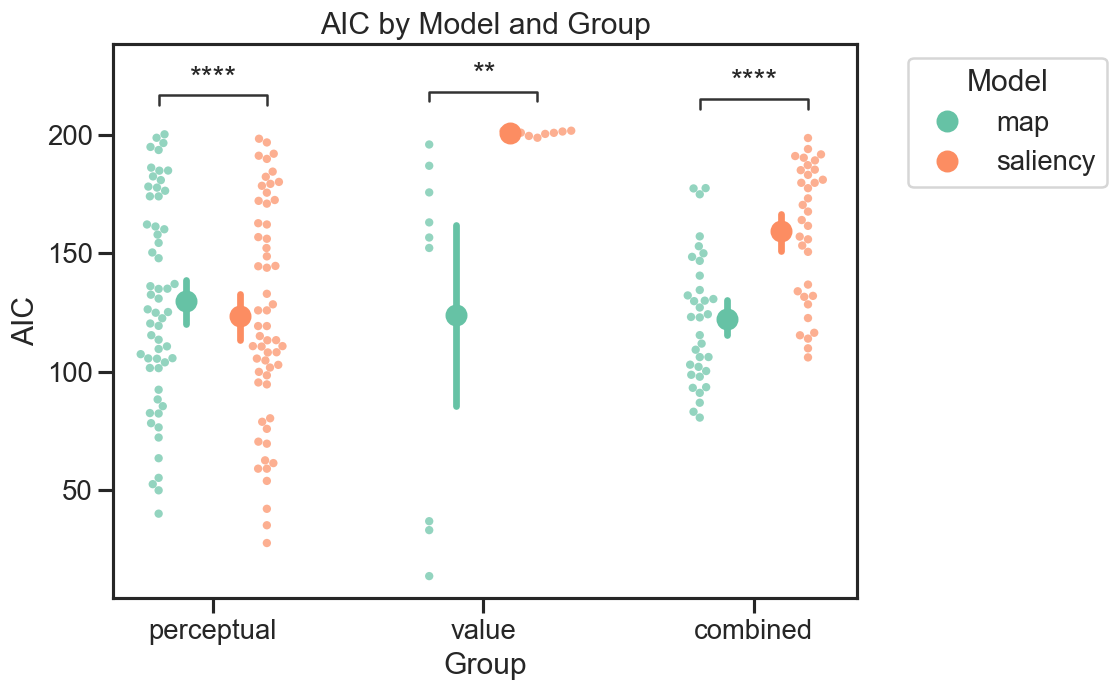

In [69]:
# plot BIC depending on model and group
import matplotlib.pyplot as plt
y = 'AIC'
order = ['perceptual', 'value', 'combined']
sns.set_context('talk')
plt.figure(figsize=(8, 6))
# sns.boxplot(data=data, x='group', y=y, hue='model', linewidth=3)
sns.pointplot(data=data, x='group', y=y, hue='model', order=order,
               dodge=0.2, join=False, markers='o', ci=90)
sns.swarmplot(data=data, x='group', y=y, hue='model', dodge=True, alpha=0.7, order=order)

plt.title(f'{y} by Model and Group')
plt.xlabel('Group') 

# use statannotations to add statistical comparisons
from statannotations.Annotator import Annotator
pairs = [
    (('value', 'map'), ('value', 'saliency')),
    (('perceptual', 'map'), ('perceptual', 'saliency')),
    (('combined', 'map'), ('combined', 'saliency')),
]
annotator = Annotator(plt.gca(), pairs, data=data, x='group', y=y, hue='model', order=order)
annotator.configure(test='Wilcoxon', text_format='star', loc='inside', verbose=False)
annotator.apply_and_annotate()
handles, labels = plt.gca().get_legend_handles_labels()
plt.gca().legend(handles[0:2], labels[0:2], title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')

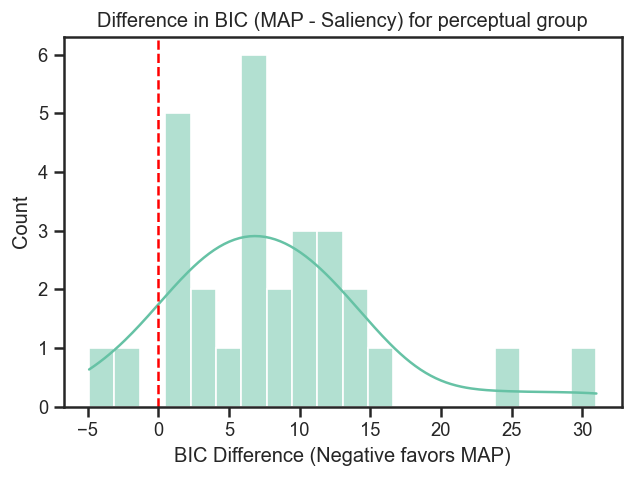

Group: perceptual
Mean difference (MAP - Saliency): 8.08 (SD: 7.45)
Paired t-test: t = 5.85, p = 2.77e-06
Subjects favoring MAP (lower BIC): 2/29 (6.9%)
Subjects favoring Saliency: 27/29 (93.1%)


In [40]:
# Detailed analysis of the difference for the perceptual group
group_name = 'perceptual'
subset = data[data['group'] == group_name]

# Pivot to get paired data
pivot_data = subset.pivot(index='prolificID', columns='model', values='BIC')
pivot_data['diff'] = pivot_data['map'] - pivot_data['saliency']

# Plot differences
plt.figure(figsize=(6, 4))
sns.histplot(pivot_data['diff'], kde=True, bins=20)
plt.axvline(x=0, color='red', linestyle='--')
plt.title(f'Difference in BIC (MAP - Saliency) for {group_name} group')
plt.xlabel('BIC Difference (Negative favors MAP)')
plt.show()

# Statistics
mean_diff = pivot_data['diff'].mean()
std_diff = pivot_data['diff'].std()
t_stat, p_val = stats.ttest_rel(pivot_data['map'], pivot_data['saliency'])
n_favors_map = (pivot_data['diff'] < 0).sum()
n_favors_saliency = (pivot_data['diff'] > 0).sum()
total = len(pivot_data)

print(f"Group: {group_name}")
print(f"Mean difference (MAP - Saliency): {mean_diff:.2f} (SD: {std_diff:.2f})")
print(f"Paired t-test: t = {t_stat:.2f}, p = {p_val:.2e}")
print(f"Subjects favoring MAP (lower BIC): {n_favors_map}/{total} ({n_favors_map/total:.1%})")
print(f"Subjects favoring Saliency: {n_favors_saliency}/{total} ({n_favors_saliency/total:.1%})")


C:\Users\garciaba\AppData\Local\Temp\ipykernel_24764\1899969539.py:20: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.violinplot(data=data, x="model", y="BIC", palette=palette, split=True, gap=0.3,


NameError: name 'd_' is not defined

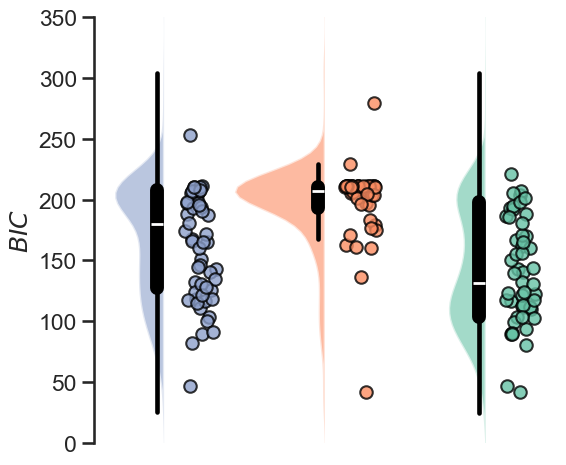

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# --- Prepare plot --- #
sns.set({'figure.figsize': (6, 5)})
sns.set_context('talk')
sns.set_style('ticks')
sns.set_palette('Set2')
palette = ['C2', 'C1', 'C0']
order = ['perceptual', 'value', 'map']

group_positions = {g: i for i, g in enumerate(order)}
group_names = order

df = data[(data.group!='random') & (data.exp=='FullPilot12')].copy()
# --- Violin plots --- #
sns.violinplot(data=data, x="model", y="BIC", palette=palette, split=True, gap=0.3,
               hue=True, hue_order=[True, False], alpha=.6, linecolor='w', zorder=0,
                 inner_kws={'color': 'black', 'box_width': 10}, inner='box', order=order)


# --- Manually set half violin colors --- #
ax = plt.gca()
plt.xlabel('')
plt.ylabel('$BIC$')
plt.ylim(0, 350)
# remove xticks labels 
plt.xticks(range(len(group_names)), [''] * len(group_names), rotation=0)
for i, collection in enumerate(ax.collections):
    if hasattr(collection, 'get_paths') and len(collection.get_paths()) > 0:
        # This is a violin body
        violin_idx = i # Each violin has 2 collections (left and right halves)
        if violin_idx < len(palette):
            collection.set_facecolor(palette[violin_idx])
            collection.set_alpha(0.6)

# --- Stripplot with controlled jitter --- #
jitter_strength = 0.1
bias_to_right = .5
dot_coords = []  # store jittered (x, y, subject)

for i, group in enumerate(group_names):
    subset = df[df["model"] == group]
    jittered_x = i + np.random.uniform(-jitter_strength, jitter_strength, size=len(subset))
    jittered_x += bias_to_right
    y_vals = subset["BIC"].values
    subj_ids = subset["prolificID"].values

    # if the max value overall is detected, set ax
    if df["BIC"].max() in y_vals:
        plt.scatter(jittered_x, y_vals, color=palette[i], alpha=0.8, zorder=3, edgecolors='black')
    else:
        plt.scatter(jittered_x, y_vals, color=palette[i], alpha=0.8, zorder=3, edgecolors='black')

    # Save jittered coordinates and subjects
    for x, y, s in zip(jittered_x, y_vals, subj_ids):
        dot_coords.append({"subject": s, "group": group, "x": x, "y": y})


# --- Aesthetics --- #
bias_x_axis = 0.25
# plt.title("Raincloud Plot with Controlled Jitter & Connections", fontsize=14)
# plt.xticks(range(len(group_names)), [1, 2, 3])
# plt.xticks([i + bias_x_axis for i in range(len(group_names))], [''], rotation=0)

sns.despine(bottom=True)
plt.tick_params(axis='x', which='both', bottom=False, top=False)

# the y axis ticks should only show from 0 to 1
# plt.yticks(np.arange(0, 1.1, 0.2))
# add horizontal line at y=0.5
# plt.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, zorder=1)
sns.despine(trim=True, bottom=True)
plt.tight_layout()
plt.legend().remove()

from statannotations.Annotator import Annotator
import itertools

# Create pairs of experiments for annotation
pairs = list(itertools.combinations(order, 2))
annotator = Annotator(ax,  pairs, x='model', y='BIC',
                     data=data, order=order)
# annotator.configure(test='t-test_ind', text_format='star', loc='outside').apply_test()
# test should be mann-whitney u test
annotator.configure(test='t-test_paired', text_format='star', loc='outside').apply_test()

annotator.annotate_custom_annotations([s[:-1] + f' $d={d:.2f}$' for s, d in zip(annotator.get_annotations_text(), d_)])




C:\Users\basil\AppData\Local\Temp\ipykernel_5588\2005350497.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.pointplot(x='model', y='BIC', data=data, join=False, errorbar='se',
C:\Users\basil\AppData\Local\Temp\ipykernel_5588\2005350497.py:24: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  ax = sns.pointplot(x='model', y='BIC', data=data, join=False, errorbar='se',
C:\Users\basil\AppData\Local\Temp\ipykernel_5588\2005350497.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='model', y='BIC', data=data, palette=palette, alpha=0.6, ax=ax, order=order,


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

perceptual vs. value: **** $d=0.94$
value vs. map: **** $d=1.28$
perceptual vs. map: *** $d=0.32$
perceptual - t-statistic: 11.685, p-value: 0.000
value - t-statistic: 28.017, p-value: 0.000
map - t-statistic: 8.722, p-value: 0.000


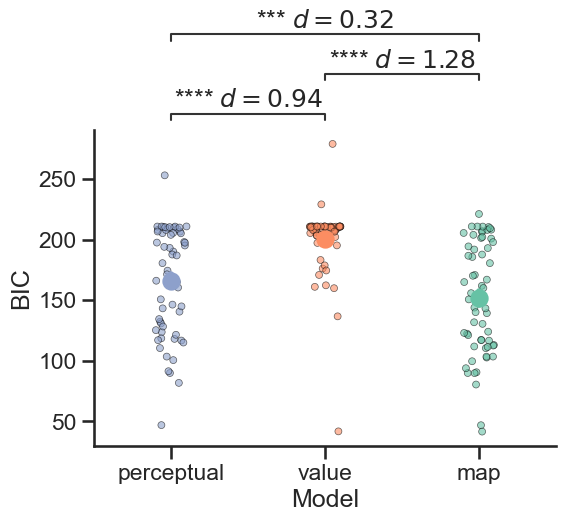

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statannotations.Annotator import Annotator
import itertools
import pingouin as pg
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests

# --- Setup --- #
sns.set({"figure.figsize": (6, 6), 'figure.dpi': 100})
sns.set_style("ticks")
sns.set_context("talk")
sns.set_palette("Set2")

palette = ['C2', 'C1', 'C0']
order = ['perceptual', 'value', 'map']

# --- Data preparation --- #
data = df_fit[df_fit.exp == 'FullPilot12'].groupby(['model', 'prolificID']).last().reset_index()

# --- Plot --- #
ax = sns.pointplot(x='model', y='BIC', data=data, join=False, errorbar='se',
                   palette=palette, order=order, zorder=10)
sns.stripplot(x='model', y='BIC', data=data, palette=palette, alpha=0.6, ax=ax, order=order,
              edgecolor='black', linewidth=0.5)

plt.xlabel('Model')
plt.ylabel('BIC')
sns.despine()

# --- Statistical annotations (paired t-test) --- #
pairs = list(itertools.combinations(order, 2))
annotator = Annotator(ax, pairs, x='model', y='BIC', data=data, order=order)
annotator.configure(test='t-test_paired', text_format='star', loc='outside').apply_test()

# --- Effect size computation (Cohen's d) --- #
d_ = []
for (i, j) in pairs:
    d = pg.compute_effsize(data[data.model == i]['BIC'],
                           data[data.model == j]['BIC'],
                           eftype='cohen', paired=True)  # use paired=True since it's the same subjects
    d_.append(abs(d))

annotator.annotate_custom_annotations(
    [s + f' $d={d:.2f}$' for s, d in zip(annotator.get_annotations_text(), d_)]
)

# --- One-sample t-tests against a reference value (optional, e.g., test vs. mean BIC=100) --- #
bic_reference = 100
for model in order:
    group_data = data[data.model == model]['BIC']
    t_stat, p_value = stats.ttest_1samp(group_data, bic_reference)
    _, p_value_corrected, _, _ = multipletests([p_value], method='bonferroni')
    p_value = p_value_corrected[0]
    print(f"{model} - t-statistic: {t_stat:.3f}, p-value: {p_value:.3f}")

plt.tight_layout()


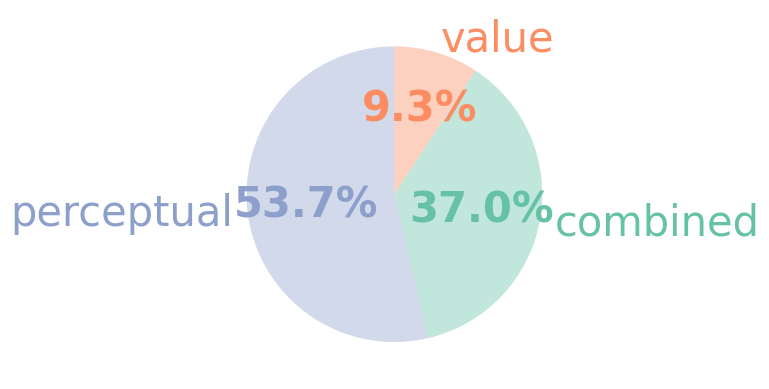

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt


sns.set_palette('Set2')
# Data
groups =  ['perceptual', 'combined', 'value']
exp = 'FullPilot14'
means = df_fit[(df_fit.exp==exp) & (df_fit.group!='random')].groupby('prolificID').last().group.value_counts(normalize=True)
means = means.reindex(groups, fill_value=0)  # Ensures all groups exist in the expected order
# sort means by groups
means = means.loc[groups].values
# Explode Shoes slice
# explode = (0, 0.1, 0)  # Explode each slice slightly

colors = ['C2', 'C0', 'C1']
# colors with alpha = 0.5
colors2 = [(r, g, b, 0.4) for r, g, b in sns.color_palette('Set2')]
# select 0, 2, 7, 1
colors2 = [colors2[i] for i in [2, 0, 1]]

# Create pie chart
wedges, texts, autotexts = plt.pie(means, labels=groups,  colors=colors2, autopct='%1.1f%%', startangle=90)

for i, autotext in enumerate(autotexts):
    autotext.set_color(colors[i])
    autotext.set_fontsize(30)
    autotext.set_fontweight('bold')

for i, text in enumerate(texts):
    text.set_color(colors[i])
    text.set_fontsize(30)



In [39]:

from scipy.stats import chi2_contingency
# how to statistically compare the proportion of groups across experiments?
# we can use a chi-squared test
import numpy as np
import scipy.stats as stats
# chi-squared test
# print(stats.chi2_contingency(proportion.groupby(['expName', 'group']).proportion.sum().unstack().T))
import pingouin as pg
# use pingouin to do pairwise wilcoxon tests
#create a df containing each prolificID and the group it belongs to and the expName
# df_ = df.groupby(['prolificID', 'expName'], as_index=False).group2.first()
df_fit = pd.read_csv('../data/processed/omega_fit_full.csv')
df_ = df_fit[df_fit.group!='random']


expected, observed, stats = pg.chi2_independence(data=df_, x='exp', y='group', correction=True)
# pg.pairwise_tests(data=proportion, dv='proportion', between='expName', within='group', padjust='bonf', within_first=False)from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_['exp'], df_['group'])
chi2, p, dof, ex = chi2_contingency(contingency_table)

n = contingency_table.sum().sum()
r, k = contingency_table.shape
cramers_v = np.sqrt(chi2 / (n * min(r-1, k-1)))
# Print results
print("Chi-squared test statistic:", np.round(chi2, 3))
print('Cramer\'s V:', np.round(cramers_v, 3))
print("p-value:", np.round(p,4))


Chi-squared test statistic: 29.018
Cramer's V: 0.267
p-value: 0.0001


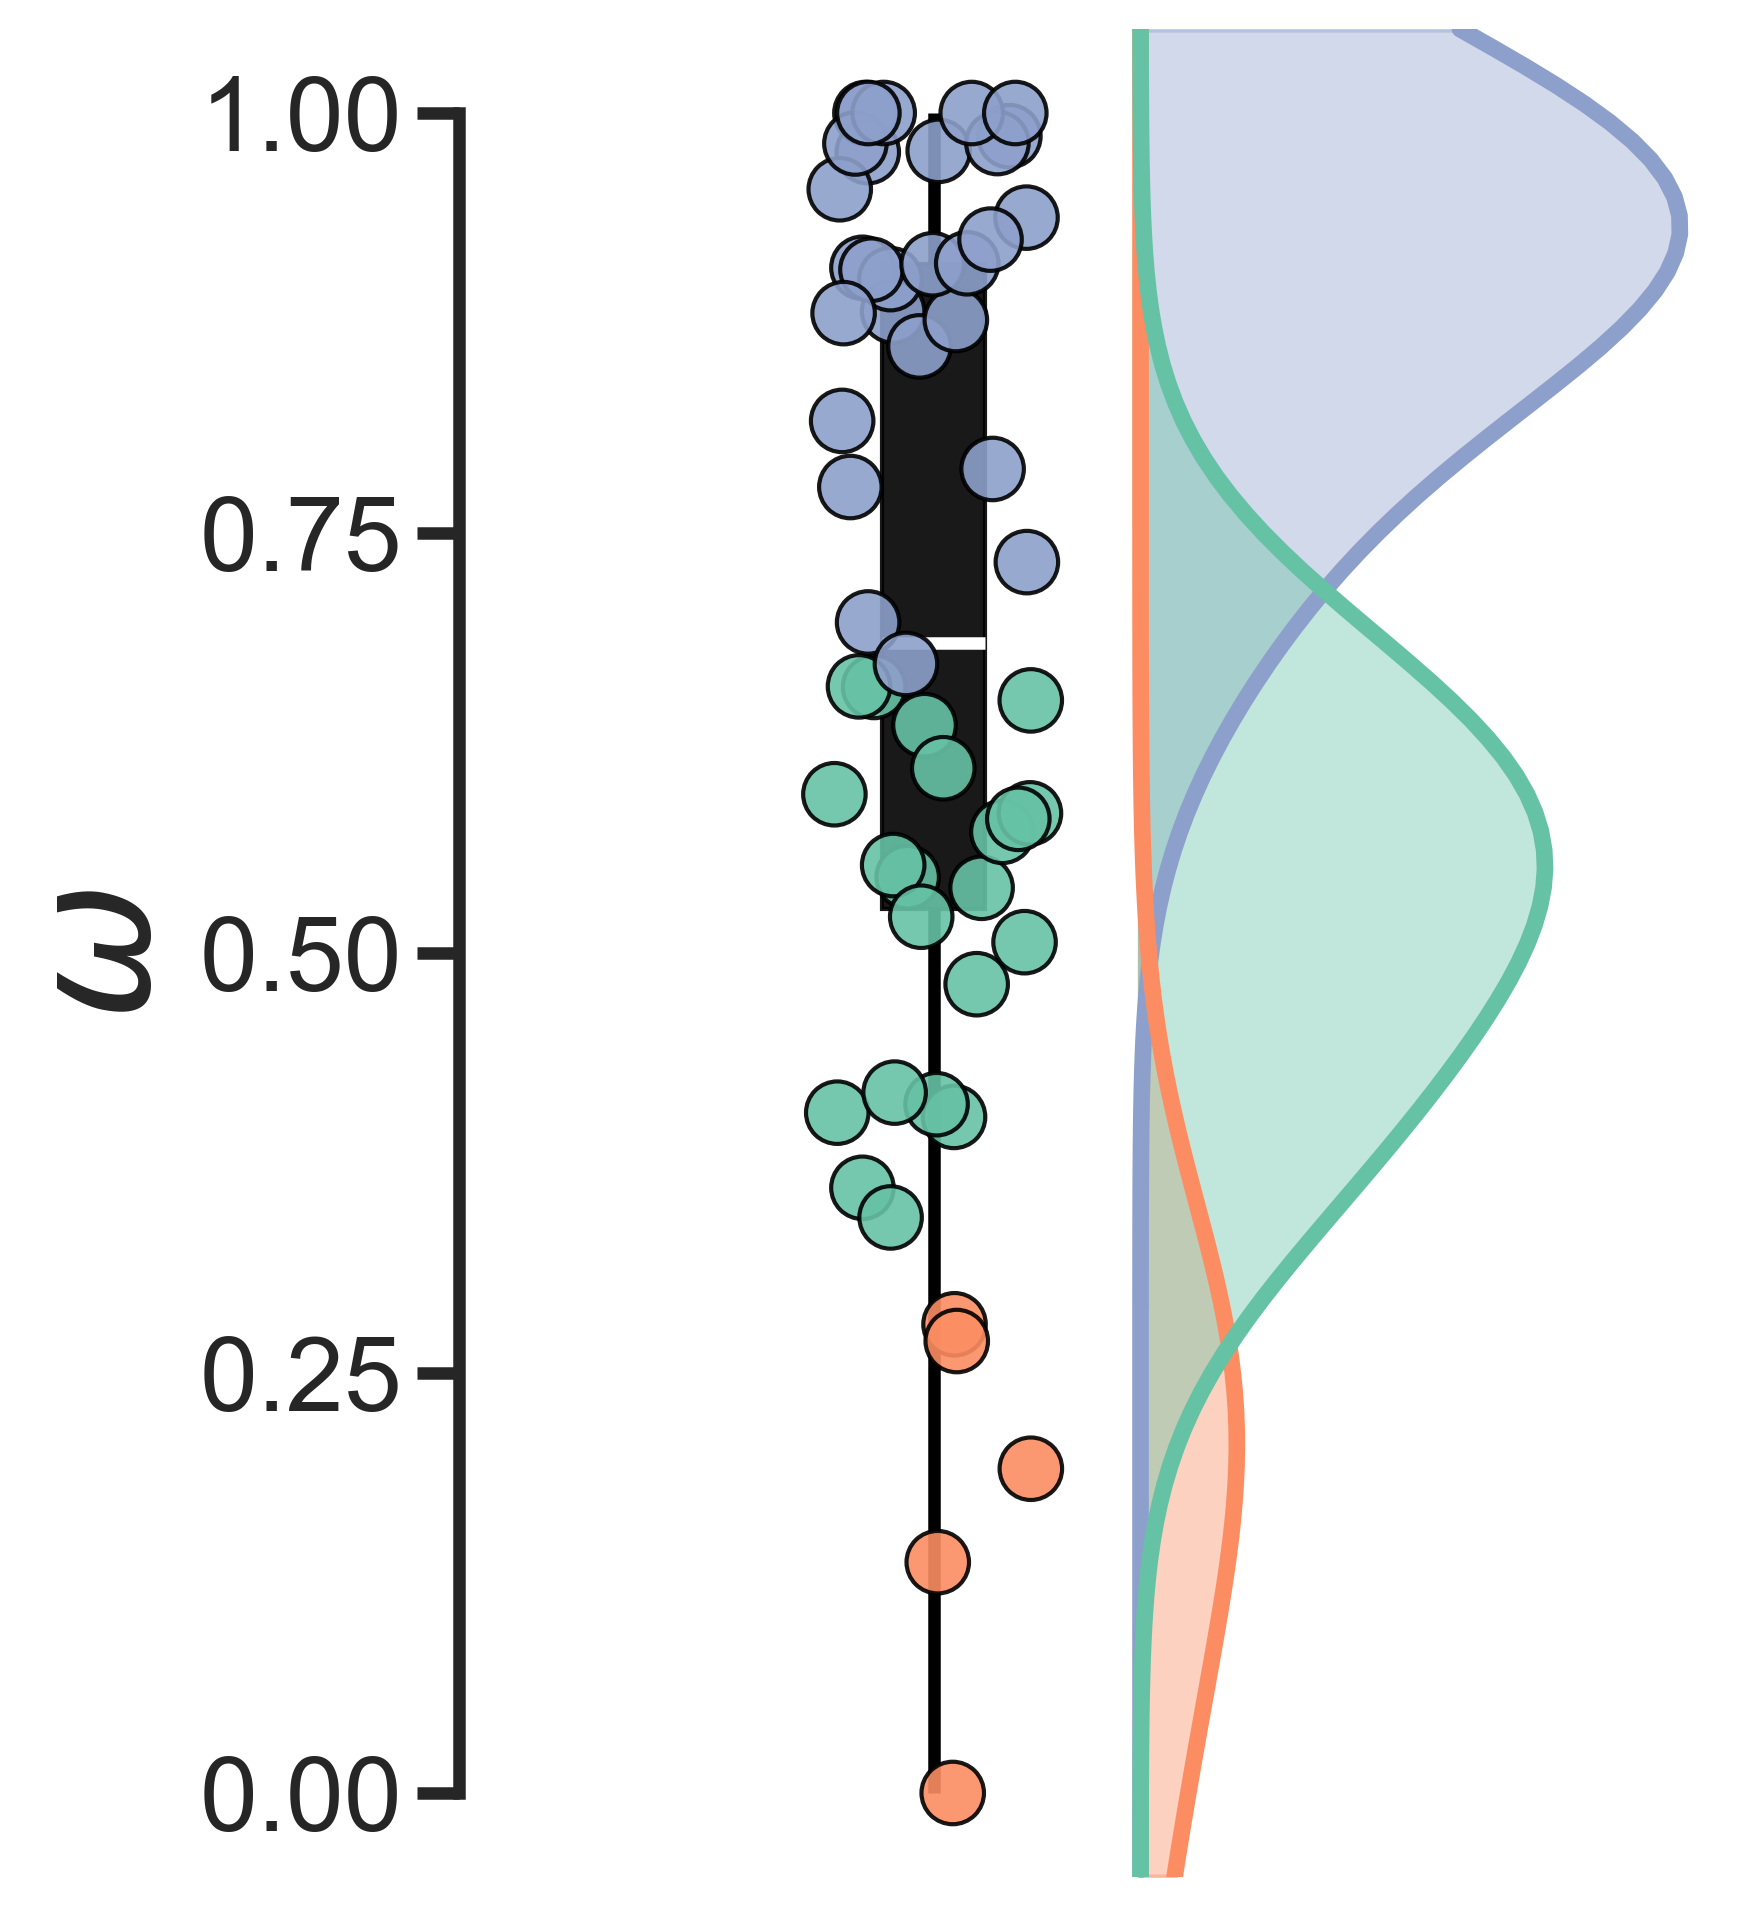

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

# I've created a dummy dataframe to make the code runnable.
# You should use your original dataframe.
np.random.seed(42)
exp_ = 'FullPilot14'
# df_fit['group2'] = df_fit.apply(lambda x: df[(df.prolificID == x.agent)]['group'].values[0], axis=1)
delta = df_fit[(df_fit.model=='map') & (df_fit.exp==exp_) & (df_fit.group!='random')].groupby(['agent', 'group', 'model', 'exp']).last().reset_index()

agent = delta.agent.values
group = delta.group.values
model = delta.model.values
exp = delta.exp

dd2 = pd.DataFrame({
    'agent': agent,
    'expName': exp,
    'group': group,
    'model': model,
    'delta': delta.omega.values,
    'll': delta.ll.values,
})

dd2 = dd2[(dd2.expName==exp_) & (dd2.group.isin(['value', 'perceptual', 'combined']))]
groups = dd2.group.unique()
# in groups the order should be ['perceptual', 'value', 'combined']
# Sort groups to ensure consistent order
groups = sorted(groups, key=lambda x: ['perceptual', 'value', 'combined'].index(x))

groups = dd2.group.unique()
groups = sorted(groups, key=lambda x: ['perceptual', 'value', 'combined'].index(x))
palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
sns.set({'figure.figsize': (5, 8), 'figure.dpi': 100})
sns.set_style('ticks')
sns.set_context('talk')

palette = sns.color_palette('Set2')
palette = [palette[2], palette[1], palette[0]]
dot_position = -.5

kde_start = 0.2

# --- Start of new code ---
# Added the boxplot here

# plot horizontal line, grey dotted, at y=.33 and .66

# plot it manually
plt.figure(figsize=(4, 8), dpi=300)
sns.set_context('talk')

sns.boxplot(y='delta', data=dd2, color='black', width=0.1, x=np.ones(len(dd2))*dot_position,
            boxprops=dict(facecolor='black', zorder=1, alpha=0.9),
            whiskerprops=dict(color='black', zorder=1, linewidth=3),
            capprops=dict(color='black', zorder=1, linewidth=0),
            medianprops=dict(color='white', zorder=2, linewidth=3),
            showfliers=False, # Do not show outlier fliers
            saturation=1,
            ax=plt.gca() # Use the current axes
            )
# --- End of new code ---

# Draw the stripplot on the left
sns.stripplot(data=dd2, x=np.ones(len(dd2))*dot_position, y='delta', hue='group',
              hue_order=groups, palette=palette,
              edgecolor='black', size=15, linewidth=1, alpha=0.9, zorder=2) # zorder > boxplot zorder
# Replace stripplot with swarmplot to arrange dots according to their density
# sns.swarmplot(data=dd2, y='delta', hue='group',
#               hue_order=groups, palette='Set2',
#               edgecolor='black', size=10, linewidth=1, # Reduced size from 15 for a better layout
#               alpha=0.7, zorder=2, legend=False)
plt.ylim(-.05, 1.05)

# --- Start of modified code ---

# Define the points for density evaluation based on the total sample
x_pts = np.linspace(dd2.delta.min() - 0.05, dd2.delta.max() + 0.05, 100)

# Calculate overall KDE for scaling reference
overall_kde = stats.gaussian_kde(dd2['delta'].values, bw_method=1)
overall_density = overall_kde(x_pts)
max_overall_density = overall_density.max()

for i, group_name in enumerate(groups):
    subset = dd2[dd2.group == group_name]
    
    # Calculate KDE for this group
    group_kde = stats.gaussian_kde(subset['delta'].values, bw_method=1)
    group_density = group_kde(x_pts)
    
    # Scale by group size and normalize by overall max for consistent scaling
    scaled_density = (group_density / group_density.max()) * len(subset) / len(dd2) * max_overall_density **0.1
    
    plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color=palette[i], alpha=0.4)
    plt.plot(kde_start + scaled_density, x_pts, color=palette[i], lw=4)

# # 1. First, calculate all densities and find the global maximum
# all_densities = []
# for group_name in groups:
#     subset = dd2[dd2.group == group_name]
#     kde = stats.gaussian_kde(subset['delta'].values, bw_method=1)
#     density = kde(x_pts)
#     all_densities.append(density)

# all_densities = [x**3 for x in all_densities]
# # Find the peak density value across all calculated densities
# global_max_density = np.max(all_densities)

# # 2. Now, plot each KDE, scaling by the global maximum density
# for i, (group_name, density) in enumerate(zip(groups, all_densities)):
#     # Scale density for visibility using the global max
#     scaled_density = density / global_max_density * 0.5  # Scale to make it visible but not too wide
    
#     # Plot the KDE curve horizontally
#     plt.fill_betweenx(x_pts, kde_start, kde_start + scaled_density, color=palette[i], alpha=0.4)
#     plt.plot(kde_start + scaled_density, x_pts, color=palette[i], lw=4)

# --- End of modified code ---

plt.xticks([], [])
plt.ylabel('$\\omega$')
plt.yticks(np.arange(0, 1.1, .25), fontsize=40)
handles, labels = plt.gca().get_legend_handles_labels()
# compute the N for each group
N = [len(dd2[dd2.group==g]) for g in groups]
labels = [f'{label} ({n})' for label, n in zip(labels, N)]
# legend outside the plot
# plt.legend(handles[:3], labels[:3], title='behavioral group', bbox_to_anchor=(1, 1), loc='upper left')
plt.legend(title='',  labels=labels, handles=handles[:3], bbox_to_anchor=(1.7, .6), fontsize=20, 
              borderaxespad=0.)
plt.legend().remove()

sns.despine(trim=True, bottom=True, offset=80)
plt.xlabel('')
plt.ylabel('$\\omega$', fontdict={'fontsize': 40})
# change y tick label size
plt.yticks(fontsize=25)

#change axis width y  axis
plt.gca().spines['left'].set_linewidth(3)
# tick width
plt.gca().tick_params(width=3, length=10)